# IMPORT LIBRARIES


In [86]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)

SYNTHETIC DATASET GENERATION
10000 samples
800 features
10 classes


In [87]:
num_samples = 10000

img_height = 20
img_width = 30
num_features = img_height * img_width  # 20 x 30 = 600 features

num_classes = 5

# Random grayscale values (0-255)


In [88]:
X = np.random.randint(0, 256, size=(num_samples, num_features))

# Normalize to 0-1


In [89]:
X = X / 255.0

# Random labels


In [90]:
y = np.random.randint(0, num_classes, size=(num_samples,))

print("Input Shape :", X.shape)

Input Shape : (10000, 600)


# DISPLAY SAMPLE PSEUDO IMAGE


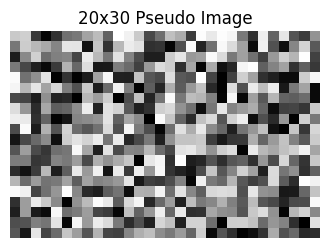

In [91]:
plt.figure(figsize=(4, 3))

sample_image = X[0].reshape(img_height, img_width)

plt.imshow(sample_image, cmap='gray')

plt.title("20x30 Pseudo Image")

plt.axis('off')

plt.show()

# ONE HOT ENCODING


In [92]:
def one_hot_encode(y, num_classes):

    one_hot = np.zeros((len(y), num_classes))

    for i in range(len(y)):
        one_hot[i, y[i]] = 1

    return one_hot


y_encoded = one_hot_encode(y, num_classes)

# TRAIN TEST SPLIT


In [93]:
def train_test_split(X, y, test_size=0.2):

    num_samples = X.shape[0]

    indices = np.arange(num_samples)

    np.random.shuffle(indices)

    split_index = int(num_samples * (1 - test_size))

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (8000, 600)
Testing Shape  : (2000, 600)


# ACTIVATION FUNCTIONS


In [94]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)


def tanh(z):
    return np.tanh(z)


def tanh_derivative(a):
    return 1 - np.square(a)


def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# LOSS FUNCTION


In [95]:
def cross_entropy_loss(y_true, y_pred):

    epsilon = 1e-10

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    return loss

# ACCURACY FUNCTION


In [96]:
def compute_accuracy(y_true, y_pred):

    y_true_labels = np.argmax(y_true, axis=1)

    y_pred_labels = np.argmax(y_pred, axis=1)

    accuracy = np.mean(y_true_labels == y_pred_labels)

    return accuracy

# NEURAL NETWORK CLASS


In [97]:
class NeuralNetwork:

    def __init__(
        self,
        input_size,
        hidden1,
        hidden2,
        output_size,
        activation='relu',
        learning_rate=0.01
    ):

        self.lr = learning_rate
        self.activation_name = activation

        # ====================================================
        # WEIGHT INITIALIZATION
        # ====================================================

        self.W1 = np.random.randn(
            input_size,
            hidden1
        ) * 0.01

        self.b1 = np.zeros((1, hidden1))

        self.W2 = np.random.randn(
            hidden1,
            hidden2
        ) * 0.01

        self.b2 = np.zeros((1, hidden2))

        self.W3 = np.random.randn(
            hidden2,
            output_size
        ) * 0.01

        self.b3 = np.zeros((1, output_size))

    # ========================================================
    # ACTIVATION SELECTOR
    # ========================================================

    def activation(self, z):

        if self.activation_name == 'sigmoid':
            return sigmoid(z)

        elif self.activation_name == 'tanh':
            return tanh(z)

        else:
            return relu(z)

    # --------------------------------------------------------

    def activation_derivative(self, a, z):

        if self.activation_name == 'sigmoid':
            return sigmoid_derivative(a)

        elif self.activation_name == 'tanh':
            return tanh_derivative(a)

        else:
            return relu_derivative(z)

    # ========================================================
    # FORWARD PROPAGATION
    # ========================================================

    def forward(self, X):

        # Hidden Layer 1
        self.Z1 = np.dot(X, self.W1) + self.b1

        self.A1 = self.activation(self.Z1)

        # Hidden Layer 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2

        self.A2 = self.activation(self.Z2)

        # Output Layer
        self.Z3 = np.dot(self.A2, self.W3) + self.b3

        self.A3 = softmax(self.Z3)

        return self.A3

    # ========================================================
    # BACKPROPAGATION
    # ========================================================

    def backward(self, X, y):

        m = X.shape[0]

        # ====================================================
        # OUTPUT LAYER
        # ====================================================

        dZ3 = self.A3 - y

        dW3 = np.dot(self.A2.T, dZ3) / m

        db3 = np.sum(
            dZ3,
            axis=0,
            keepdims=True
        ) / m

        # ====================================================
        # HIDDEN LAYER 2
        # ====================================================

        dA2 = np.dot(dZ3, self.W3.T)

        dZ2 = dA2 * self.activation_derivative(
            self.A2,
            self.Z2
        )

        dW2 = np.dot(self.A1.T, dZ2) / m

        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        ) / m

        # ====================================================
        # HIDDEN LAYER 1
        # ====================================================

        dA1 = np.dot(dZ2, self.W2.T)

        dZ1 = dA1 * self.activation_derivative(self.A1, self.Z1)

        dW1 = np.dot(X.T, dZ1) / m

        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ====================================================
        # GRADIENT DESCENT UPDATE
        # ====================================================

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ========================================================
    # TRAINING FUNCTION
    # ========================================================

    def train(self, X, y, epochs=100):

        losses = []
        accuracies = []

        for epoch in range(epochs):

            predictions = self.forward(X)

            loss = cross_entropy_loss(y, predictions)

            accuracy = compute_accuracy(y, predictions)

            self.backward(X, y)

            losses.append(loss)
            accuracies.append(accuracy)

            if epoch % 10 == 0:

                print(
                    f"Epoch {epoch} | "
                    f"Loss = {loss:.4f} | "
                    f"Accuracy = {accuracy:.4f}"
                )

        return losses, accuracies

DIFFERENT HIDDEN LAYER CONFIGURATIONS


In [98]:
hidden_layer_configs = [

    (64, 32),

    (128, 64),

]

ACTIVATION FUNCTIONS


In [99]:
activation_functions = [

    'relu',

    'sigmoid',

    'tanh'

]

# TRAIN MODELS


In [100]:
results = {}

for activation in activation_functions:

    for config in hidden_layer_configs:

        print("\n========================================")
        print(f"Activation Function : {activation}")
        print(f"Hidden Layers       : {config}")
        print("========================================")

        model = NeuralNetwork(

            input_size=600,

            hidden1=config[0],

            hidden2=config[1],

            output_size=5,

            activation=activation,

            learning_rate=0.01
        )

        losses, accuracies = model.train(

            X_train,

            y_train,

            epochs=50
        )

        key = f"{activation}_{config}"

        results[key] = {

            'losses': losses,

            'accuracies': accuracies
        }


Activation Function : relu
Hidden Layers       : (64, 32)
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2090
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057

Activation Function : relu
Hidden Layers       : (128, 64)
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2077
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2059
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057

Activation Function : sigmoid
Hidden Layers       : (64, 32)
Epoch 0 | Loss = 1.6093 | Accuracy = 0.2057
Epoch 10 | Loss = 1.6093 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6093 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6093 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6093 | Accuracy = 0.2057

Activation Function : sigmoid
Hidden Layers       : (128, 64)
Epoch 0 | Loss = 1.6101 | Accuracy = 0.2016
Epoch 10 | Loss = 1.6097 | Accuracy = 0.

# PLOT LOSS CURVES


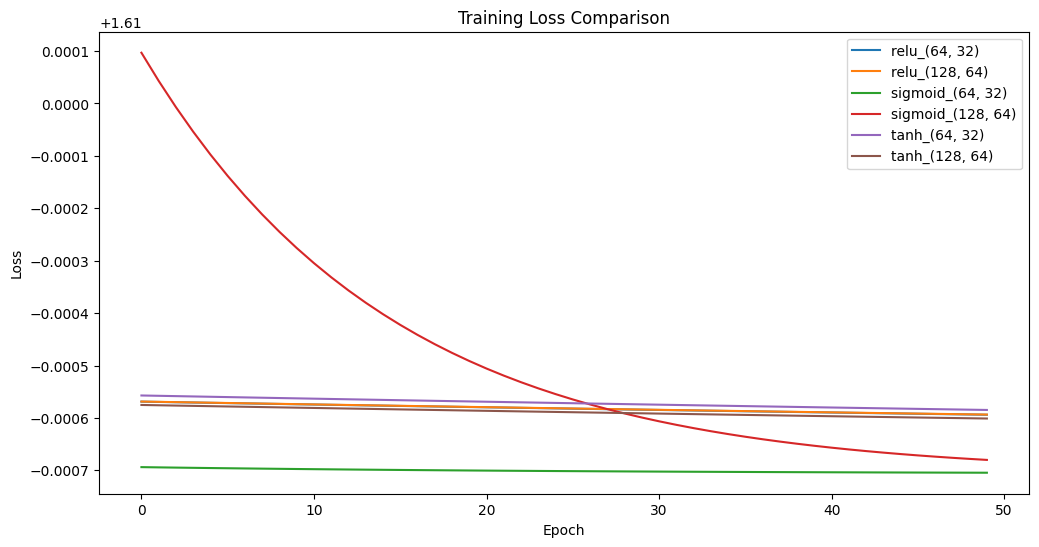

In [101]:
plt.figure(figsize=(12, 6))

for key in results:

    plt.plot(results[key]['losses'], label=key)

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# PLOT ACCURACY CURVES


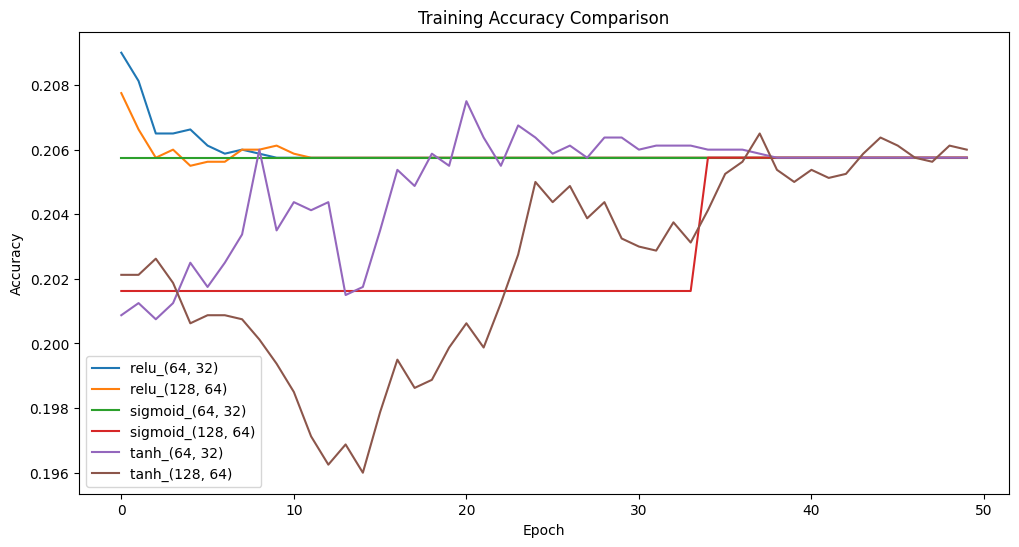

In [102]:
plt.figure(figsize=(12, 6))

for key in results:

    plt.plot(results[key]['accuracies'], label=key)

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# LEARNING RATE EXPERIMENT



Training with Learning Rate = 0.001
Epoch 0 | Loss = 1.6094 | Accuracy = 0.1994
Epoch 10 | Loss = 1.6094 | Accuracy = 0.1993
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2005
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2028
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2037

Training with Learning Rate = 0.01
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2039
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2018
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2037
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2030
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2060

Training with Learning Rate = 0.05
Epoch 0 | Loss = 1.6094 | Accuracy = 0.1994
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057

Training with Learning Rate = 0.1
Epoch 0 | Loss = 1.6094 | Accuracy = 0.1930
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6093 | Accuracy = 0.2057
Epoch

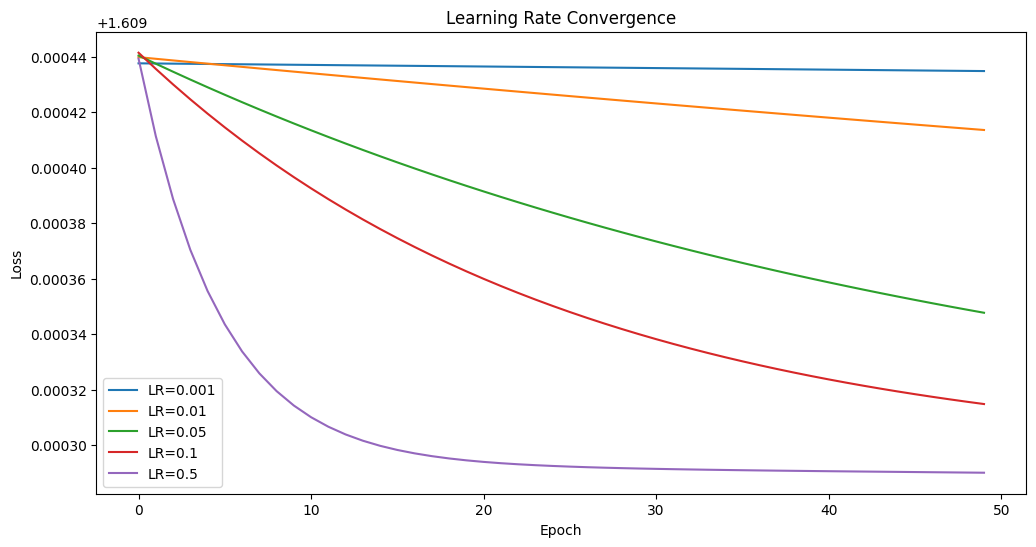

In [103]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(12, 6))

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = NeuralNetwork(

        input_size=600,

        hidden1=64,

        hidden2=32,
        
        output_size=5,

        activation='relu',

        learning_rate=lr
    )

    losses, _ = model.train(

        X_train,

        y_train,

        epochs=50
    )

    plt.plot(losses, label=f"LR={lr}")

plt.title("Learning Rate Convergence")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# EPOCH EXPERIMENT



Training for 50 epochs
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2023
Epoch 10 | Loss = 1.6094 | Accuracy = 0.1978
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2056
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2060
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057


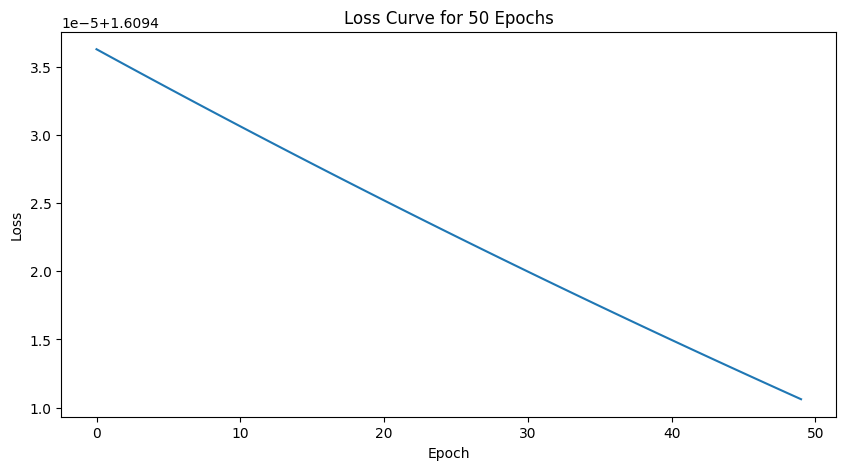


Training for 100 epochs
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2019
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 50 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 60 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 70 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 80 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 90 | Loss = 1.6094 | Accuracy = 0.2057


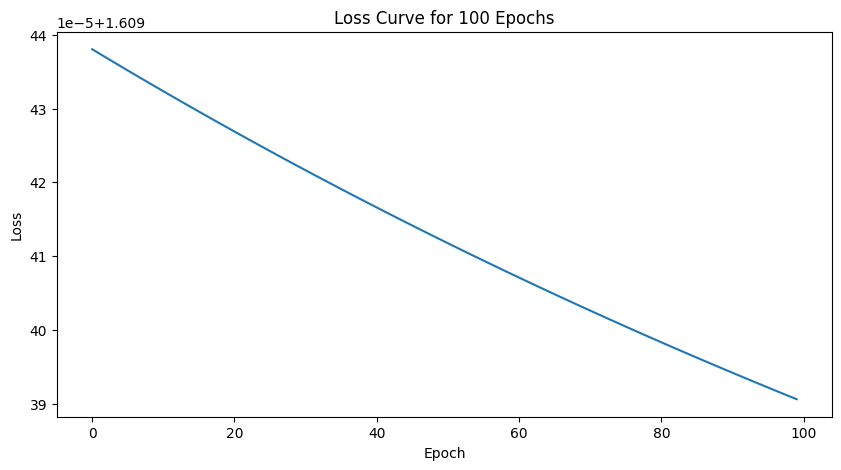


Training for 200 epochs
Epoch 0 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 50 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 60 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 70 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 80 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 90 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 100 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 110 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 120 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 130 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 140 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 150 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 160 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 170 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 180 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 190 | Loss = 1.6094 | Accuracy = 0.2057


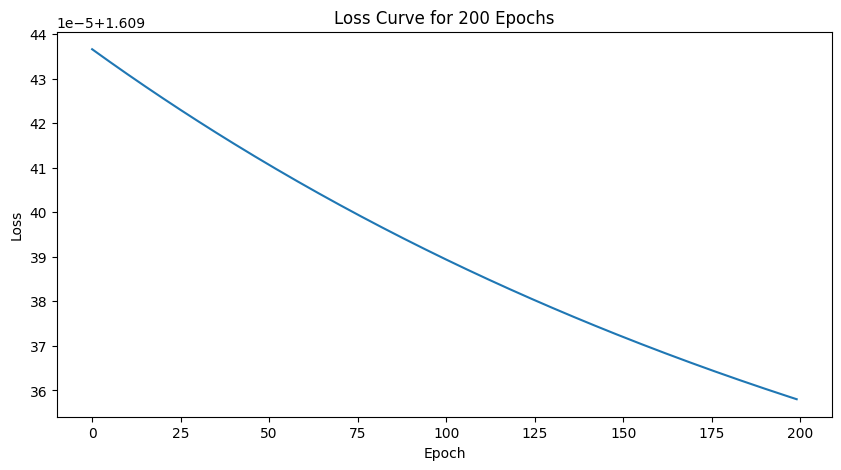


Training for 500 epochs
Epoch 0 | Loss = 1.6094 | Accuracy = 0.1984
Epoch 10 | Loss = 1.6094 | Accuracy = 0.2056
Epoch 20 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 30 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 40 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 50 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 60 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 70 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 80 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 90 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 100 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 110 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 120 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 130 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 140 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 150 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 160 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 170 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 180 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 190 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 200 | Loss = 1.6094 | Accuracy = 0.2057
Epoch 210 | Loss = 1

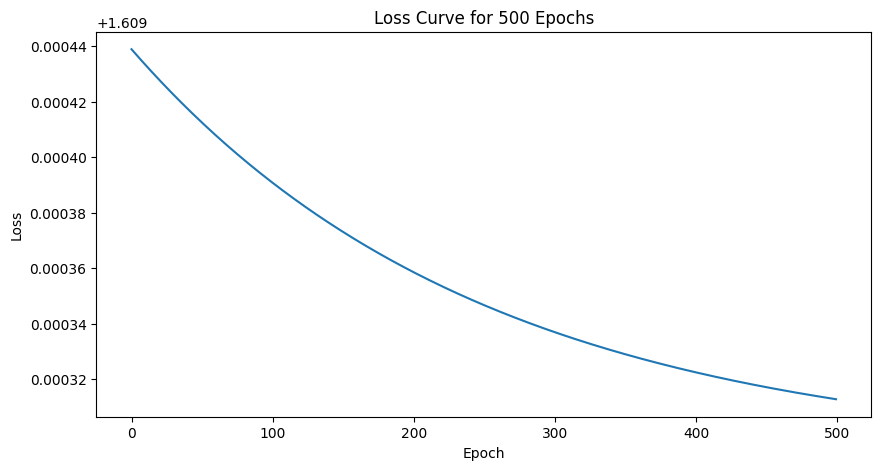

In [104]:
epoch_values = [50, 100, 200, 500]

for ep in epoch_values:

    print("\n================================")
    print(f"Training for {ep} epochs")
    print("================================")

    model = NeuralNetwork(

        input_size=600,

        hidden1=64,

        hidden2=32,

        output_size=5,

        activation='relu',

        learning_rate=0.01
    )

    losses, accuracies = model.train(

        X_train,

        y_train,

        epochs=ep
    )

    plt.figure(figsize=(10, 5))

    plt.plot(losses)

    plt.title(f"Loss Curve for {ep} Epochs")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.show()

# FINAL TEST ACCURACY


In [105]:
final_predictions = model.forward(X_test)

test_accuracy = compute_accuracy(
    y_test,
    final_predictions
)

print("\nFinal Test Accuracy :", test_accuracy)


Final Test Accuracy : 0.1935
